11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


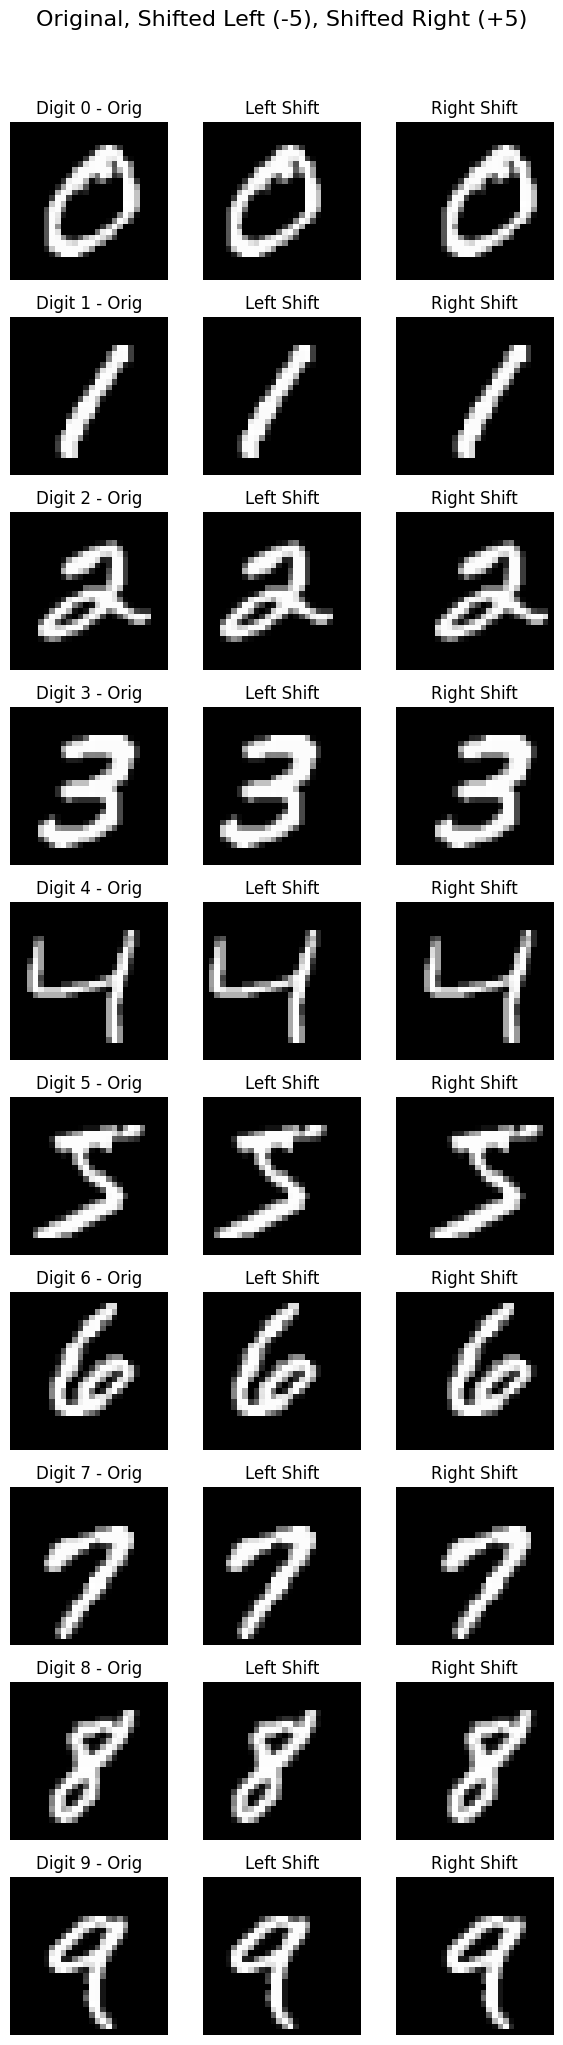

In [ ]:
"""
This script demonstrates the shifting of images from the MNIST dataset, which contains handwritten digits.

The code performs the following steps:

1. **Load the MNIST Dataset**: It imports the MNIST dataset using TensorFlow's Keras API, which contains
     training images and their corresponding labels.

2. **Shift Image Function**: A function `shift_image` is defined to shift an input image by specified amounts
     in the x (horizontal) and y (vertical) directions. The function uses the `shift` method from the `scipy.ndimage`
      module, with a constant mode that fills the empty areas with zeros.

3. **Collect Samples**: The script collects one example image for each digit (0-9) from the training dataset.
     This is done by iterating through the unique digit labels and selecting the first occurrence of each digit.

4. **Create Plots**: A subplot grid is created using Matplotlib to display the original images alongside their
    shifted versions. Each row corresponds to a different digit, and three columns show the original image, the
    image shifted left by 2 pixels, and the image shifted right by 2 pixels.

5. **Display the Plot**: The final plot is displayed with appropriate titles for each image, and axes are turned
     off for a cleaner look.

Dependencies:
- numpy
- matplotlib
- tensorflow
- scipy

Usage:
Run the script in an environment where the required libraries are installed. The output will be a visual
representation of the original and shifted images for each digit in the MNIST dataset.
"""

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from scipy.ndimage import shift

# Load MNIST dataset
(x_train, y_train), (_, _) = mnist.load_data()

# Function to shift image
def shift_image(img, dx=0, dy=0):
    return shift(img, shift=[dy, dx], mode='constant', cval=0)

# Collect one example per class
samples = []
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    samples.append(x_train[idx])

# Create plot
fig, axes = plt.subplots(nrows=10, ncols=3, figsize=(6, 20))
fig.suptitle("Original, Shifted Left (-5), Shifted Right (+5)", fontsize=16, y=1.02)

for i, img in enumerate(samples):
    shifted_left = shift_image(img, dx=-2)
    shifted_right = shift_image(img, dx=2)

    # Original
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f"Digit {i} - Orig")

    # Shifted Left
    axes[i, 1].imshow(shifted_left, cmap='gray')
    axes[i, 1].set_title("Left Shift")

    # Shifted Right
    axes[i, 2].imshow(shifted_right, cmap='gray')
    axes[i, 2].set_title("Right Shift")

    for ax in axes[i]:
        ax.axis('off')

plt.tight_layout()
plt.show()


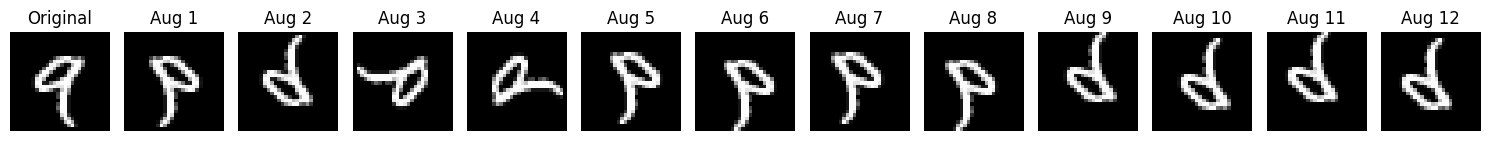

In [ ]:
"""
Image Augmentation for MNIST Dataset

This script performs image augmentation on a single image from the MNIST dataset, specifically targeting images of class '2'. The augmentation process includes flipping, rotating, and translating the image to generate a variety of augmented images. The original and augmented images are then displayed using Matplotlib.

Modules Used:
- OpenCV (cv2): For image processing tasks such as flipping, rotating, and translating images.
- NumPy: For numerical operations and handling image arrays.
- Matplotlib: For visualizing the original and augmented images.
- TensorFlow Keras: For loading the MNIST dataset.

Functions:
- augment_image(img):
    Takes a single image as input and returns a list of augmented images. The augmentations include:
    - Horizontal and vertical flips
    - 90-degree clockwise rotations of the flipped images
    - Translations of ±5% of the image's width and height for the flipped images

Usage:
1. Load the MNIST dataset and extract an image of class '2'.
2. Call the `augment_image` function with the selected image.
3. Visualize the original and augmented images using Matplotlib.

Note:
- The augmented images are generated based on simple transformations and may not represent complex augmentations typically used in deep learning applications.
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load MNIST dataset
(x_train, y_train), (_, _) = mnist.load_data()

# Find one image of class 0
img = x_train[y_train == 9][0]

# Augmentation function
def augment_image(img):
    augmented_images = []

    # Flip and rotate
    imgFH = cv2.flip(img, 1)  # Horizontal Flip
    augmented_images.append(imgFH)

    imgFV = cv2.flip(img, 0)  # Vertical Flip
    augmented_images.append(imgFV)

    imgRFH = cv2.rotate(imgFH, cv2.ROTATE_90_CLOCKWISE)
    augmented_images.append(imgRFH)

    imgRFV = cv2.rotate(imgFV, cv2.ROTATE_90_CLOCKWISE)
    augmented_images.append(imgRFV)

    # Get image dimensions
    (height, width) = img.shape[:2]

    # Translations: ±20% width and height
    tx = int(0.05 * width)
    ty = int(0.05 * height)

    translations = [
        (tx, -ty),
        (tx, ty),
        (-tx, -ty),
        (-tx, ty),
    ]

    base_variants = [imgFH, imgFV]
    for base_img in base_variants:
        for tx_val, ty_val in translations:
            M = np.float32([[1, 0, tx_val], [0, 1, ty_val]])
            translated_img = cv2.warpAffine(base_img, M, (width, height), borderValue=0)
            augmented_images.append(translated_img)

    return augmented_images

# Apply augmentation
augmented_imgs = augment_image(img)

# Plot original + augmented
n_aug = len(augmented_imgs)
plt.figure(figsize=(15, 3))

# Show original image
plt.subplot(1, n_aug + 1, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

# Show augmented images
for i, aug_img in enumerate(augmented_imgs):
    plt.subplot(1, n_aug + 1, i + 2)
    plt.imshow(aug_img, cmap='gray')
    plt.title(f"Aug {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.79MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.33MB/s]


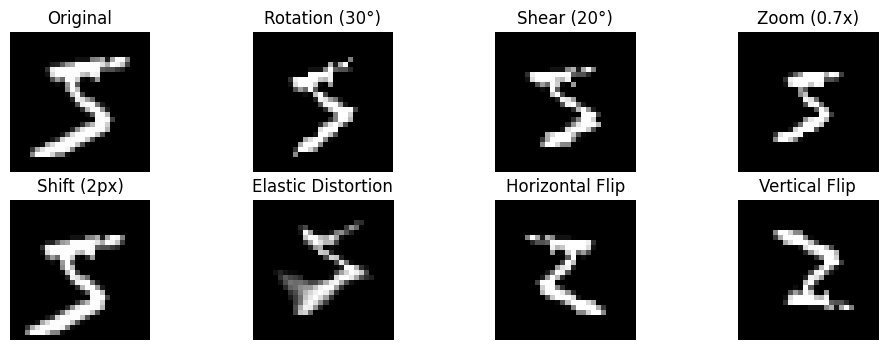

In [ ]:
"""
Image Augmentation for MNIST Dataset

This script performs various image augmentations on a single sample image from the MNIST dataset, specifically targeting images of a specified class (e.g., class '5'). The augmentations include horizontal and vertical flips, rotations, shearing, zooming, shifting, and elastic distortions. The original and augmented images are then displayed using Matplotlib.

Modules Used:
- PyTorch (torch): For loading the MNIST dataset and performing transformations.
- torchvision: For dataset handling and image transformations.
- Matplotlib: For visualizing the original and augmented images.
- NumPy: For numerical operations and handling image arrays.
- PIL (Pillow): For image processing tasks.
- SciPy: For advanced image processing functions such as Gaussian filtering and coordinate mapping.

Functions:
- hflip_aug(img):
    Applies horizontal flip augmentation to the input image after zooming out.

- vflip_aug(img):
    Applies vertical flip augmentation to the input image after zooming out.

- center_image(image: Image.Image) -> Image.Image:
    Centers the digit in the image based on the center of mass of white pixels.

- zoom_out(img, scale=0.8):
    Zooms out the input image by a specified scale using a random affine transformation.

- elastic_transform(image, alpha=26, sigma=3):
    Applies elastic distortion to the input image using Gaussian noise.

- rotation_aug(img):
    Applies rotation augmentation to the input image after zooming out.

- shear_aug(img):
    Applies shear augmentation to the input image after zooming out.

- elastic_aug(img):
    Applies elastic distortion augmentation to the input image after zooming out and centers the result.

Usage:
1. Load the MNIST dataset and extract an image of the specified target class.
2. Define the desired augmentations in a dictionary.
3. Apply each augmentation to the selected image.
4. Visualize the original and augmented images using Matplotlib.

Note:
- The augmentations are designed to enhance the diversity of the training data, which can improve the performance of machine learning models.
- The original image is also centered before displaying to ensure consistent visualization.
"""

import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageEnhance
from scipy.ndimage import gaussian_filter, map_coordinates
from PIL import ImageOps
from torchvision.transforms import functional as TF
from scipy.ndimage import center_of_mass, shift

# Load MNIST
mnist_data = datasets.MNIST(root='./data', train=True, download=True)

# Pick one sample from a target class (e.g., '7')
target_class = 5
for img, label in mnist_data:
    if label == target_class:
        base_image = img
        break

def hflip_aug(img):
    img = zoom_out(img, scale=0.8)
    img = TF.hflip(img)
    return center_image(img)

def vflip_aug(img):
    img = zoom_out(img, scale=0.8)
    img = TF.vflip(img)
    return center_image(img)


def center_image(image: Image.Image) -> Image.Image:
    """
    Center the digit in the image based on the center of mass of white pixels.
    """
    img_array = np.array(image)
    if img_array.max() > 1:
        img_array = img_array / 255.0  # Normalize to 0-1 if needed

    cy, cx = center_of_mass(img_array)
    shift_y = int(round(img_array.shape[0] / 2 - cy))
    shift_x = int(round(img_array.shape[1] / 2 - cx))
    shifted_img = shift(img_array, shift=(shift_y, shift_x), mode='constant', cval=0.0)
    return Image.fromarray((shifted_img * 255).astype(np.uint8))


# Zoom-out helper using RandomAffine
def zoom_out(img, scale=0.8):
    return transforms.RandomAffine(degrees=0, scale=(scale, scale))(img)

# Elastic Transform function
def elastic_transform(image, alpha=26, sigma=3):
    image = np.array(image)
    random_state = np.random.RandomState(15)

    shape = image.shape
    dx = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha
    dy = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha

    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = np.reshape(y + dy, (-1, 1)), np.reshape(x + dx, (-1, 1))

    distorted_image = map_coordinates(image, indices, order=1, mode='reflect').reshape(shape)
    return Image.fromarray(distorted_image)


# Wrap transformations that need pre-scaling
def rotation_aug(img):
    img = zoom_out(img, scale=0.8)
    return transforms.RandomRotation(degrees=30)(img)

def shear_aug(img):
    img = zoom_out(img, scale=0.8)
    return transforms.RandomAffine(degrees=0, shear=20)(img)

def elastic_aug(img):
    img = zoom_out(img, scale=0.8)
    img = elastic_transform(img)
    img = center_image(img)
    return img


# Augmentations
augmentations = {
    # "Rotation (30°)": transforms.RandomRotation(degrees=30),
    "Rotation (30°)": rotation_aug,
    # "Shear (20°)": transforms.RandomAffine(degrees=0, shear=20),
    "Shear (20°)": shear_aug,
    "Zoom (0.7x)": transforms.RandomAffine(degrees=0, scale=(0.7, 0.7)),
    "Shift (2px)": transforms.RandomAffine(degrees=0, translate=(2/28, 2/28)),  # 2 pixels
    # "Elastic Distortion": elastic_transform
    "Elastic Distortion": elastic_aug,
    "Horizontal Flip": hflip_aug,
    "Vertical Flip": vflip_aug,
}

# Apply each augmentation individually
augmented_images = []
titles = []

for name, transform_fn in augmentations.items():
    if callable(transform_fn):
        aug_img = transform_fn(base_image)
    else:
        aug_img = transform_fn(base_image)
        aug_img = center_image(aug_img)  # Center the augmented image
    augmented_images.append(aug_img)
    titles.append(name)

# Center the original image too
base_image_centered = center_image(base_image)

# Plot Original + Augmented Images
plt.figure(figsize=(12, 4))
plt.subplot(2, 4, 1)
plt.imshow(base_image_centered, cmap='gray')
plt.title("Original")
plt.axis('off')

for i, (img, title) in enumerate(zip(augmented_images, titles), 2):
    plt.subplot(2, 4, i)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.92MB/s]


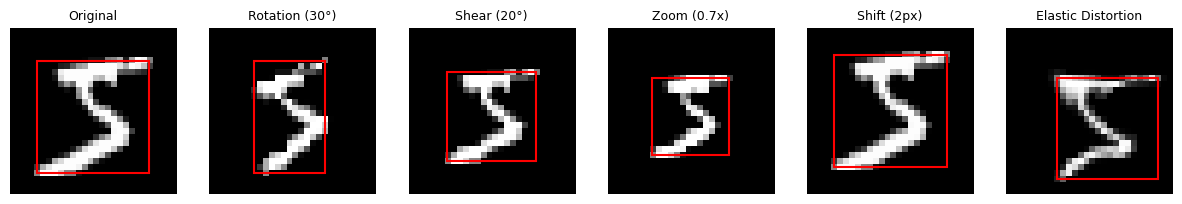

In [ ]:
"""
MNIST Data Augmentation and Bounding Box Visualization

This script demonstrates how various image augmentations affect the appearance and bounding box of a digit
in the MNIST dataset. It performs the following steps:

1. Loads the MNIST dataset and selects a single digit image from a target class.
2. Applies a set of augmentation techniques to that image, including:
   - Rotation (with pre-zooming)
   - Shear (with pre-zooming)
   - Zoom-out
   - Pixel-level Shift
   - Elastic Distortion (with re-centering)
3. Re-centers each augmented image using the center of mass to ensure the digit is visually centered.
4. Computes the bounding box around the digit in each image based on non-background pixels.
5. Visualizes the original and augmented images in a single row with their bounding boxes overlaid.

Key Features:
- Uses custom elastic transformation with Gaussian filtering and displacement fields.
- Applies matplotlib to draw bounding boxes for visual comparison.
- Demonstrates how augmentations may distort digit placement and size, and how re-centering helps preserve structure.

Dependencies:
- PyTorch
- torchvision
- PIL (Pillow)
- matplotlib
- numpy
- scipy

Useful for:
- Understanding the spatial impact of augmentation on handwritten digit recognition tasks.
- Preprocessing pipelines for robust classification with models sensitive to position and scale.

Author: ChatGpt 4o
Date: July 6, 2025
"""


import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageEnhance
from scipy.ndimage import gaussian_filter, map_coordinates
from PIL import ImageOps
from torchvision.transforms import functional as TF
from scipy.ndimage import center_of_mass, shift

# Load MNIST
mnist_data = datasets.MNIST(root='./data', train=True, download=True)

# Pick one sample from a target class (e.g., '7')
target_class = 5
for img, label in mnist_data:
    if label == target_class:
        base_image = img
        break



def center_image(image: Image.Image) -> Image.Image:
    """
    Center the digit in the image based on the center of mass of white pixels.
    """
    img_array = np.array(image)
    if img_array.max() > 1:
        img_array = img_array / 255.0  # Normalize to 0-1 if needed

    cy, cx = center_of_mass(img_array)
    shift_y = int(round(img_array.shape[0] / 2 - cy))
    shift_x = int(round(img_array.shape[1] / 2 - cx))
    shifted_img = shift(img_array, shift=(shift_y, shift_x), mode='constant', cval=0.0)
    return Image.fromarray((shifted_img * 255).astype(np.uint8))


# Zoom-out helper using RandomAffine
def zoom_out(img, scale=0.8):
    return transforms.RandomAffine(degrees=0, scale=(scale, scale))(img)

# Elastic Transform function
def elastic_transform(image, alpha=26, sigma=3):
    image = np.array(image)
    random_state = np.random.RandomState(6)

    shape = image.shape
    dx = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha
    dy = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha

    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = np.reshape(y + dy, (-1, 1)), np.reshape(x + dx, (-1, 1))

    distorted_image = map_coordinates(image, indices, order=1, mode='reflect').reshape(shape)
    return Image.fromarray(distorted_image)


# Wrap transformations that need pre-scaling
def rotation_aug(img):
    img = zoom_out(img, scale=0.8)
    return transforms.RandomRotation(degrees=30)(img)

def shear_aug(img):
    img = zoom_out(img, scale=0.8)
    return transforms.RandomAffine(degrees=0, shear=20)(img)

def elastic_aug(img):
    img = zoom_out(img, scale=0.8)
    img = elastic_transform(img)
    img = center_image(img)
    return img

from matplotlib.patches import Rectangle

def get_bounding_box(img: Image.Image):
    """Returns the bounding box (x, y, w, h) for the white digit in the image."""
    arr = np.array(img)
    if arr.max() <= 1:
        arr = (arr * 255).astype(np.uint8)

    # Threshold to binary
    binary = arr > 30  # threshold to separate digit from background

    coords = np.argwhere(binary)
    if coords.size == 0:
        return None  # completely blank
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    return x0, y0, x1 - x0, y1 - y0


# Augmentations
augmentations = {
    # "Rotation (30°)": transforms.RandomRotation(degrees=30),
    "Rotation (30°)": rotation_aug,
    # "Shear (20°)": transforms.RandomAffine(degrees=0, shear=20),
    "Shear (20°)": shear_aug,
    "Zoom (0.7x)": transforms.RandomAffine(degrees=0, scale=(0.7, 0.7)),
    "Shift (2px)": transforms.RandomAffine(degrees=0, translate=(2/28, 2/28)),  # 2 pixels
    # "Elastic Distortion": elastic_transform
    "Elastic Distortion": elastic_aug
}

# Apply each augmentation individually
augmented_images = []
titles = []

for name, transform_fn in augmentations.items():
    if callable(transform_fn):
        aug_img = transform_fn(base_image)
    else:
        aug_img = transform_fn(base_image)
        aug_img = center_image(aug_img)  # Center the augmented image
    augmented_images.append(aug_img)
    titles.append(name)

# Center the original image too
base_image_centered = center_image(base_image)

# Plot Original + Augmented Images
plt.figure(figsize=(15, 4))
images_to_plot = [base_image_centered] + augmented_images
titles_to_plot = ["Original"] + titles

for i, (img, title) in enumerate(zip(images_to_plot, titles_to_plot), 1):
    ax = plt.subplot(1, 6, i)
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=9)
    ax.axis('off')

    # Draw bounding box
    box = get_bounding_box(img)
    if box:
        x, y, w, h = box
        rect = Rectangle((x, y), w, h, linewidth=1.5, edgecolor='red', facecolor='none')
        ax.add_patch(rect)




In [ ]:
"""
Full MNIST Augmentation for MLP Training

This script applies multiple transformations to all 60,000 training images from the MNIST dataset to create an augmented dataset suitable for training a Multi-Layer Perceptron (MLP). The augmentations include zooming out, rotations, shearing, elastic distortions, and flipping. The augmented images are saved in a specified directory, and their corresponding labels are saved in a CSV file.

Key Features:
- Each image is zoomed out to 0.8x and centered to ensure consistent positioning of the digit.
- Various augmentations are applied to enhance the diversity of the training data.
- Augmented images are saved in the 'augmented_dataset/' directory.
- Labels for the augmented images are saved in 'labels.csv'.

Modules Used:
- PyTorch (torch): For loading the MNIST dataset and performing transformations.
- torchvision: For dataset handling and image transformations.
- NumPy: For numerical operations and handling image arrays.
- PIL (Pillow): For image processing tasks.
- SciPy: For advanced image processing functions such as Gaussian filtering and coordinate mapping.
- tqdm: For displaying a progress bar during the augmentation process.
- os and csv: For file and directory management.

Functions:
- center_image(image: Image.Image) -> Image.Image:
    Centers the digit in the image based on the center of mass of white pixels.

- elastic_transform(image, alpha=26, sigma=3):
    Applies elastic distortion to the input image using Gaussian noise.

- zoom_out(img, scale=0.7):
    Zooms out the input image by a specified scale using a random affine transformation.

- rotation_aug(img):
    Applies rotation augmentation to the input image after zooming out and centers the result.

- shear_aug(img):
    Applies shear augmentation to the input image after zooming out and centers the result.

- elastic_aug(img):
    Applies elastic distortion augmentation to the input image after zooming out and centers the result.

- hflip_aug(img):
    Applies horizontal flip augmentation to the input image after zooming out and centers the result.

- vflip_aug(img):
    Applies vertical flip augmentation to the input image after zooming out and centers the result.

Usage:
1. Load the MNIST dataset and set up the directory for saving augmented images and labels.
2. Define the desired augmentations in a dictionary.
3. Process each image in the dataset, apply the augmentations, and save the results.
4. The augmented images will be saved in the specified directory, and their labels will be recorded in a CSV file.

Note:
- The augmentations are designed to enhance the diversity of the training data, which can improve the performance of machine learning models.
- Ensure that the necessary libraries are installed and the dataset is downloaded before running the script.
"""


import torch
from torchvision import datasets, transforms
import numpy as np
from PIL import Image
from scipy.ndimage import gaussian_filter, map_coordinates, center_of_mass, shift
from torchvision.transforms import functional as TF
import os
import csv
from tqdm import tqdm  # Progress bar

# === Centering Function ===
def center_image(image: Image.Image) -> Image.Image:
    img_array = np.array(image)
    if img_array.max() > 1:
        img_array = img_array / 255.0
    cy, cx = center_of_mass(img_array)
    shift_y = int(round(img_array.shape[0] / 2 - cy))
    shift_x = int(round(img_array.shape[1] / 2 - cx))
    shifted_img = shift(img_array, shift=(shift_y, shift_x), mode='constant', cval=0.0)
    return Image.fromarray((shifted_img * 255).astype(np.uint8))

# === Elastic Distortion ===
def elastic_transform(image, alpha=26, sigma=3):
    image = np.array(image)
    random_state = np.random.RandomState(6)
    shape = image.shape
    dx = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha
    dy = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha
    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = np.reshape(y + dy, (-1, 1)), np.reshape(x + dx, (-1, 1))
    distorted_image = map_coordinates(image, indices, order=1, mode='reflect').reshape(shape)
    return Image.fromarray(distorted_image)

# === Zoom Helper ===
def zoom_out(img, scale=0.7):
    return transforms.RandomAffine(degrees=0, scale=(scale, scale))(img)

# === Augmentations ===
def rotation_aug(img):
    img = zoom_out(img)
    img = transforms.RandomRotation(degrees=30)(img)
    return center_image(img)

def shear_aug(img):
    img = zoom_out(img)
    img = transforms.RandomAffine(degrees=0, shear=20)(img)
    return center_image(img)


def elastic_aug(img):
    return center_image(elastic_transform(zoom_out(img)))

def hflip_aug(img):
    return center_image(TF.hflip(zoom_out(img)))

def vflip_aug(img):
    return center_image(TF.vflip(zoom_out(img)))

# === Augmentation Dictionary ===
augmentations = {
    "Original": lambda x: center_image(x),
    "Rotation": rotation_aug,
    "Shear": shear_aug,
    "ZoomOut": lambda x: center_image(transforms.RandomAffine(degrees=0, scale=(0.7, 0.7))(x)),
    "Shift": lambda x: center_image(transforms.RandomAffine(degrees=0, translate=(2/28, 2/28))(x)),
    "Elastic": elastic_aug,
    "HFlip": hflip_aug,
    "VFlip": vflip_aug,
}

# === Dataset and Save Setup ===
mnist_data = datasets.MNIST(root='./data', train=True, download=True)
save_dir = "augmented_dataset"
os.makedirs(save_dir, exist_ok=True)
csv_path = os.path.join(save_dir, "labels.csv")
csv_file = open(csv_path, mode='w', newline='')
csv_writer = csv.writer(csv_file)
csv_writer.writerow(["filename", "label"])

# === Process and Save ===
print("Generating augmented dataset...")
for idx, (img, label) in enumerate(tqdm(mnist_data)):
    for aug_name, aug_fn in augmentations.items():
        aug_img = aug_fn(img)
        filename = f"{idx:05d}_{aug_name}.png"
        aug_img.save(os.path.join(save_dir, filename))
        csv_writer.writerow([filename, label])

csv_file.close()
print(f"Saved all augmented images to '{save_dir}/' and labels to '{csv_path}'")


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 512kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.25MB/s]


Generating augmented dataset...


100%|██████████| 60000/60000 [08:47<00:00, 113.76it/s]

Saved all augmented images to 'augmented_dataset/' and labels to 'augmented_dataset/labels.csv'


In [ ]:
!zip -r augmented_dataset.zip augmented_dataset/
from google.colab import files
files.download('augmented_dataset.zip')


Streaming output truncated to the last 5000 lines.
  adding: augmented_dataset/49434_Original.png (stored 0%)
  adding: augmented_dataset/34719_ZoomOut.png (deflated 1%)
  adding: augmented_dataset/43998_Original.png (deflated 0%)
  adding: augmented_dataset/59329_Original.png (stored 0%)
  adding: augmented_dataset/29212_Elastic.png (stored 0%)
  adding: augmented_dataset/26557_Rotation.png (deflated 1%)
  adding: augmented_dataset/02360_ZoomOut.png (stored 0%)
  adding: augmented_dataset/50217_Shift.png (stored 0%)
  adding: augmented_dataset/58222_Shear.png (stored 0%)
  adding: augmented_dataset/17595_Original.png (stored 0%)
  adding: augmented_dataset/03772_HFlip.png (stored 0%)
  adding: augmented_dataset/10102_Shear.png (stored 0%)
  adding: augmented_dataset/36166_HFlip.png (deflated 1%)
  adding: augmented_dataset/32190_VFlip.png (deflated 1%)
  adding: augmented_dataset/20627_Rotation.png (deflated 1%)
  adding: augmented_dataset/10472_HFlip.png (stored 0%)
  adding: augment

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>